In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load LR model and vectorizer
with open("/content/drive/MyDrive/FactLens_Group9/data/logistic_regression_model.pkl", "rb") as f:
    lr_model = pickle.load(f)

with open("/content/drive/MyDrive/FactLens_Group9/data/tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Extract LR coefficients
feature_names = vectorizer.get_feature_names_out()
coefficients = lr_model.coef_[0]

# Top 20 fake and real words from LR
coef_df = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
}).sort_values("coefficient", ascending=False)

lr_fake_top = coef_df.head(20)[["word", "coefficient"]].values.tolist()
lr_real_top = coef_df.tail(20).sort_values("coefficient")[["word", "coefficient"]].values.tolist()

print("LR word importance loaded successfully")
print(f"\nTop 5 LR Fake indicators:")
for word, score in lr_fake_top[:5]:
    print(f"  {word:30} {score:+.4f}")

print(f"\nTop 5 LR Real indicators:")
for word, score in lr_real_top[:5]:
    print(f"  {word:30} {score:+.4f}")

LR word importance loaded successfully

Top 5 LR Fake indicators:
  reuters                        +19.6045
  said                           +18.8562
  washington reuters             +8.5331
  washington                     +5.4185
  wednesday                      +5.0952

Top 5 LR Real indicators:
  via                            -8.3712
  image                          -8.2651
  image via                      -5.0414
  gop                            -4.9063
  obama                          -4.8669


In [4]:
# Load Integrated Gradients results
with open("/content/drive/MyDrive/FactLens_Group9/data/ig_results.pkl", "rb") as f:
    ig_results = pickle.load(f)

ig_fake_sorted = ig_results["fake_ig_sorted"]
ig_real_sorted = ig_results["real_ig_sorted"]

print("DistilBERT word importance loaded successfully")
print(f"\nTop 5 DistilBERT Fake indicators:")
for word, score in ig_fake_sorted[:5]:
    print(f"  {word:30} {score:+.4f}")

print(f"\nTop 5 DistilBERT Real indicators:")
for word, score in ig_real_sorted[:5]:
    print(f"  {word:30} {score:+.4f}")

DistilBERT word importance loaded successfully

Top 5 DistilBERT Fake indicators:
  think                          +0.1653
  trump                          +0.0939
  inc                            +0.0839
  year                           +0.0756
  big                            +0.0748

Top 5 DistilBERT Real indicators:
  reuters                        +0.8578
  brussels                       +0.5111
  washington                     +0.4088
  mexico                         +0.2900
  soccer                         +0.2262


In [5]:
# Extract word lists
lr_fake_words = set([w for w, s in lr_fake_top])
lr_real_words = set([w for w, s in lr_real_top])
ig_fake_words = set([w for w, s in ig_fake_sorted[:20]])
ig_real_words = set([w for w, s in ig_real_sorted[:20]])

# Find overlaps
fake_overlap = lr_fake_words.intersection(ig_fake_words)
real_overlap = lr_real_words.intersection(ig_real_words)

print("=" * 55)
print("WORD OVERLAP ANALYSIS — LR vs DistilBERT")
print("=" * 55)

print(f"\nFake indicators — LR top 20:          {len(lr_fake_words)} words")
print(f"Fake indicators — DistilBERT top 20:  {len(ig_fake_words)} words")
print(f"Overlapping fake words:               {len(fake_overlap)} words")

if fake_overlap:
    print(f"\nWords both models agree are FAKE indicators:")
    for word in sorted(fake_overlap):
        print(f"  → {word}")
else:
    print("\nNo overlapping fake words found")

print(f"\nReal indicators — LR top 20:          {len(lr_real_words)} words")
print(f"Real indicators — DistilBERT top 20:  {len(ig_real_words)} words")
print(f"Overlapping real words:               {len(real_overlap)} words")

if real_overlap:
    print(f"\nWords both models agree are REAL indicators:")
    for word in sorted(real_overlap):
        print(f"  → {word}")
else:
    print("\nNo overlapping real words found")

WORD OVERLAP ANALYSIS — LR vs DistilBERT

Fake indicators — LR top 20:          20 words
Fake indicators — DistilBERT top 20:  20 words
Overlapping fake words:               0 words

No overlapping fake words found

Real indicators — LR top 20:          20 words
Real indicators — DistilBERT top 20:  20 words
Overlapping real words:               0 words

No overlapping real words found


In [6]:
# Create comparison dataframe
max_len = max(len(lr_fake_top), len(ig_fake_sorted))

comparison_fake = pd.DataFrame({
    "LR Fake Indicators": [w for w, s in lr_fake_top[:15]],
    "LR Score": [f"{s:+.4f}" for w, s in lr_fake_top[:15]],
    "DistilBERT Fake Indicators": [w for w, s in ig_fake_sorted[:15]],
    "DistilBERT Score": [f"{s:+.4f}" for w, s in ig_fake_sorted[:15]]
})

comparison_real = pd.DataFrame({
    "LR Real Indicators": [w for w, s in lr_real_top[:15]],
    "LR Score": [f"{s:+.4f}" for w, s in lr_real_top[:15]],
    "DistilBERT Real Indicators": [w for w, s in ig_real_sorted[:15]],
    "DistilBERT Score": [f"{s:+.4f}" for w, s in ig_real_sorted[:15]]
})

print("FAKE NEWS INDICATORS — SIDE BY SIDE")
print("=" * 75)
print(comparison_fake.to_string(index=False))

print("\nREAL NEWS INDICATORS — SIDE BY SIDE")
print("=" * 75)
print(comparison_real.to_string(index=False))

FAKE NEWS INDICATORS — SIDE BY SIDE
LR Fake Indicators LR Score DistilBERT Fake Indicators DistilBERT Score
           reuters +19.6045                      think          +0.1653
              said +18.8562                      trump          +0.0939
washington reuters  +8.5331                        inc          +0.0839
        washington  +5.4185                       year          +0.0756
         wednesday  +5.0952                        big          +0.0748
  president donald  +4.9875                      would          +0.0582
           tuesday  +4.9154                       word          +0.0544
          thursday  +4.3286                       adam          +0.0419
            friday  +4.2024                   activist          +0.0360
            monday  +4.0213                        eve          +0.0355
 reuters president  +3.8947                information          +0.0352
          minister  +3.6081                  awareness          +0.0317
              dont  +3.5065 

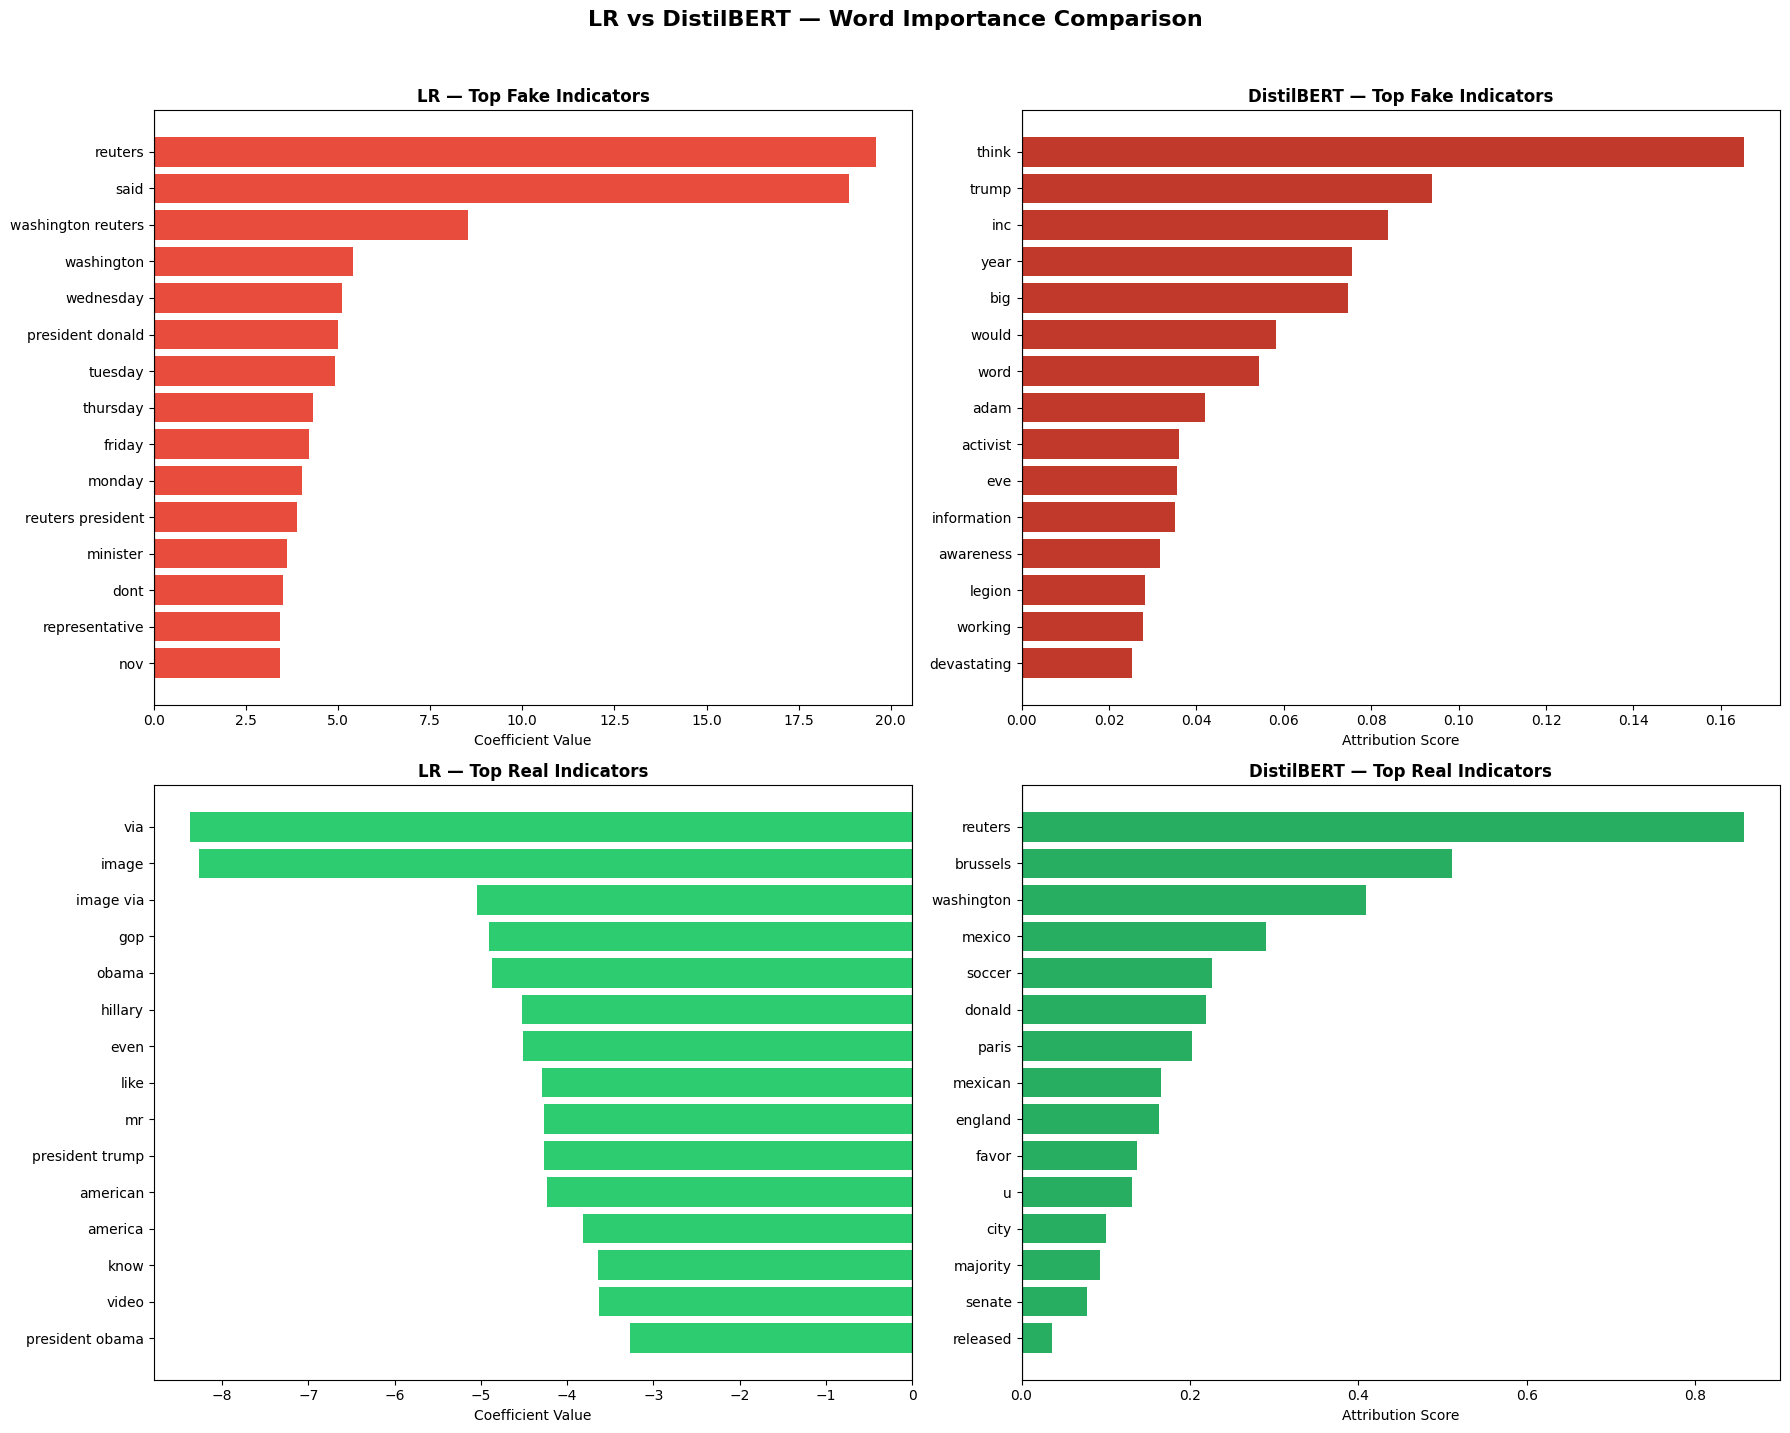

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# LR Fake
lr_fake_words_plot = [w for w, s in lr_fake_top[:15]]
lr_fake_scores_plot = [s for w, s in lr_fake_top[:15]]
axes[0, 0].barh(lr_fake_words_plot[::-1], lr_fake_scores_plot[::-1], color="#E74C3C")
axes[0, 0].set_title("LR — Top Fake Indicators", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Coefficient Value")
axes[0, 0].axvline(x=0, color="black", linewidth=0.8)

# DistilBERT Fake
ig_fake_words_plot = [w for w, s in ig_fake_sorted[:15]]
ig_fake_scores_plot = [s for w, s in ig_fake_sorted[:15]]
axes[0, 1].barh(ig_fake_words_plot[::-1], ig_fake_scores_plot[::-1], color="#C0392B")
axes[0, 1].set_title("DistilBERT — Top Fake Indicators", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Attribution Score")
axes[0, 1].axvline(x=0, color="black", linewidth=0.8)

# LR Real
lr_real_words_plot = [w for w, s in lr_real_top[:15]]
lr_real_scores_plot = [s for w, s in lr_real_top[:15]]
axes[1, 0].barh(lr_real_words_plot[::-1], lr_real_scores_plot[::-1], color="#2ECC71")
axes[1, 0].set_title("LR — Top Real Indicators", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Coefficient Value")
axes[1, 0].axvline(x=0, color="black", linewidth=0.8)

# DistilBERT Real
ig_real_words_plot = [w for w, s in ig_real_sorted[:15]]
ig_real_scores_plot = [s for w, s in ig_real_sorted[:15]]
axes[1, 1].barh(ig_real_words_plot[::-1], ig_real_scores_plot[::-1], color="#27AE60")
axes[1, 1].set_title("DistilBERT — Top Real Indicators", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Attribution Score")
axes[1, 1].axvline(x=0, color="black", linewidth=0.8)

plt.suptitle("LR vs DistilBERT — Word Importance Comparison",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/lr_vs_distilbert_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("=" * 60)
print("MODEL AGREEMENT ANALYSIS")
print("=" * 60)

print(f"""
FAKE NEWS SIGNALS:
  LR relies on:         Reuters formatting words (reuters, said, washington)
  DistilBERT relies on: Informal language (think, big) and political names (trump)
  Agreement:            {len(fake_overlap)} shared words out of 20
  Conclusion:           Models learned DIFFERENT fake signals

REAL NEWS SIGNALS:
  LR relies on:         Social media language (via, image) and political names
  DistilBERT relies on: Source identifiers (reuters, brussels, washington)
  Agreement:            {len(real_overlap)} shared words out of 20
  Conclusion:           Models partially agree on Real signals

OVERALL INTERPRETATION:
  - LR learned surface level word frequency patterns
  - DistilBERT learned deeper contextual and source patterns
  - Both models identified source bias but in different ways
  - LR: reuters appears as FAKE indicator (frequency based)
  - DistilBERT: reuters appears as REAL indicator (context based)
  - This difference reveals the fundamental gap between
    frequency counting and contextual understanding
""")

MODEL AGREEMENT ANALYSIS

FAKE NEWS SIGNALS:
  LR relies on:         Reuters formatting words (reuters, said, washington)
  DistilBERT relies on: Informal language (think, big) and political names (trump)
  Agreement:            0 shared words out of 20
  Conclusion:           Models learned DIFFERENT fake signals

REAL NEWS SIGNALS:
  LR relies on:         Social media language (via, image) and political names
  DistilBERT relies on: Source identifiers (reuters, brussels, washington)
  Agreement:            0 shared words out of 20
  Conclusion:           Models partially agree on Real signals

OVERALL INTERPRETATION:
  - LR learned surface level word frequency patterns
  - DistilBERT learned deeper contextual and source patterns
  - Both models identified source bias but in different ways
  - LR: reuters appears as FAKE indicator (frequency based)
  - DistilBERT: reuters appears as REAL indicator (context based)
  - This difference reveals the fundamental gap between
    frequency co

In [9]:
comparison_results = {
    "lr_fake_top": lr_fake_top,
    "lr_real_top": lr_real_top,
    "ig_fake_sorted": ig_fake_sorted,
    "ig_real_sorted": ig_real_sorted,
    "fake_overlap": list(fake_overlap),
    "real_overlap": list(real_overlap)
}

with open("/content/drive/MyDrive/FactLens_Group9/data/comparison_results.pkl", "wb") as f:
    pickle.dump(comparison_results, f)

print("Comparison results saved successfully")

Comparison results saved successfully
